In [1]:
!pip install xgboost
!pip install joblib

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import joblib

In [3]:
uploaded = files.upload()

Saving flood dataset.xlsx to flood dataset.xlsx
Saving rainfall in india 1901-2015.xlsx to rainfall in india 1901-2015.xlsx


In [4]:
df = pd.read_excel("/content/drive/MyDrive/Rising water/rainfall in india 1901-2015.xlsx")
df.head()

,COUNTRY,STATE,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,India,ANDAMAN & NICOBAR ISLANDS,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,India,ANDAMAN & NICOBAR ISLANDS,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,India,ANDAMAN & NICOBAR ISLANDS,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,India,ANDAMAN & NICOBAR ISLANDS,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,India,ANDAMAN & NICOBAR ISLANDS,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


In [5]:
print(df.head())

print(df.info())

print(df.describe())

print(df.isnull().sum())

  COUNTRY                      STATE  YEAR   JAN    FEB   MAR    APR    MAY  \
0   India  ANDAMAN & NICOBAR ISLANDS  1901  49.2   87.1  29.2    2.3  528.8   
1   India  ANDAMAN & NICOBAR ISLANDS  1902   0.0  159.8  12.2    0.0  446.1   
2   India  ANDAMAN & NICOBAR ISLANDS  1903  12.7  144.0   0.0    1.0  235.1   
3   India  ANDAMAN & NICOBAR ISLANDS  1904   9.4   14.7   0.0  202.4  304.5   
4   India  ANDAMAN & NICOBAR ISLANDS  1905   1.3    0.0   3.3   26.9  279.5   

     JUN    JUL    AUG    SEP    OCT    NOV    DEC  ANNUAL  Jan-Feb  Mar-May  \
0  517.5  365.1  481.1  332.6  388.5  558.2   33.6  3373.2    136.3    560.3   
1  537.1  228.9  753.7  666.2  197.2  359.0  160.5  3520.7    159.8    458.3   
2  479.9  728.4  326.7  339.0  181.2  284.4  225.0  2957.4    156.7    236.1   
3  495.1  502.0  160.1  820.4  222.2  308.7   40.1  3079.6     24.1    506.9   
4  628.7  368.7  330.5  297.0  260.7   25.4  344.7  2566.7      1.3    309.7   

   Jun-Sep  Oct-Dec  
0   1696.3    980.3  


In [6]:
df["Flood"] = (df["ANNUAL"] > 2000).astype(int)

df.head()

,COUNTRY,STATE,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,...,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,Flood
0,India,ANDAMAN & NICOBAR ISLANDS,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,...,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3,1
1,India,ANDAMAN & NICOBAR ISLANDS,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,...,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7,1
2,India,ANDAMAN & NICOBAR ISLANDS,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,...,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6,1
3,India,ANDAMAN & NICOBAR ISLANDS,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,...,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0,1
4,India,ANDAMAN & NICOBAR ISLANDS,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,...,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8,1


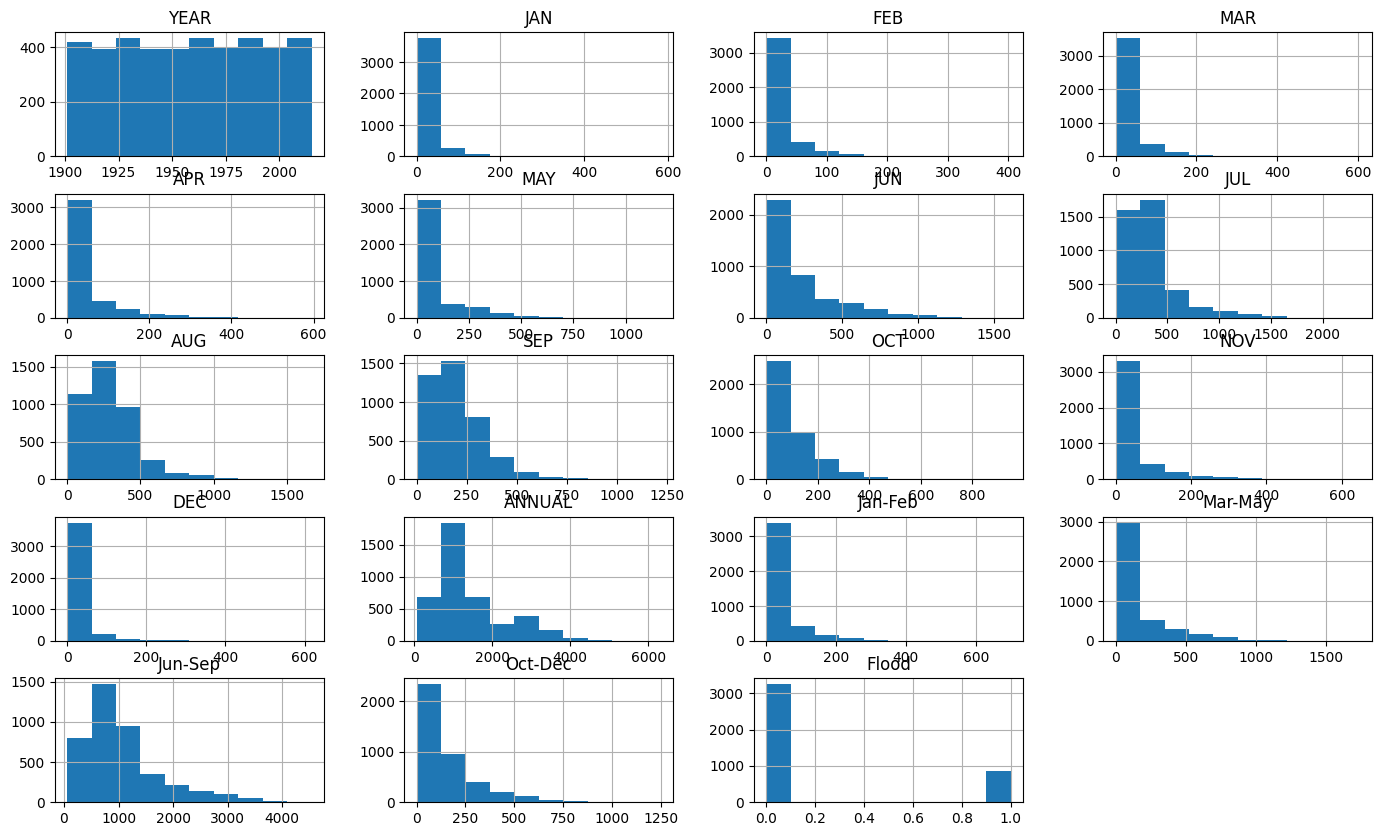

In [8]:
df.hist(figsize=(17,10))
plt.show()

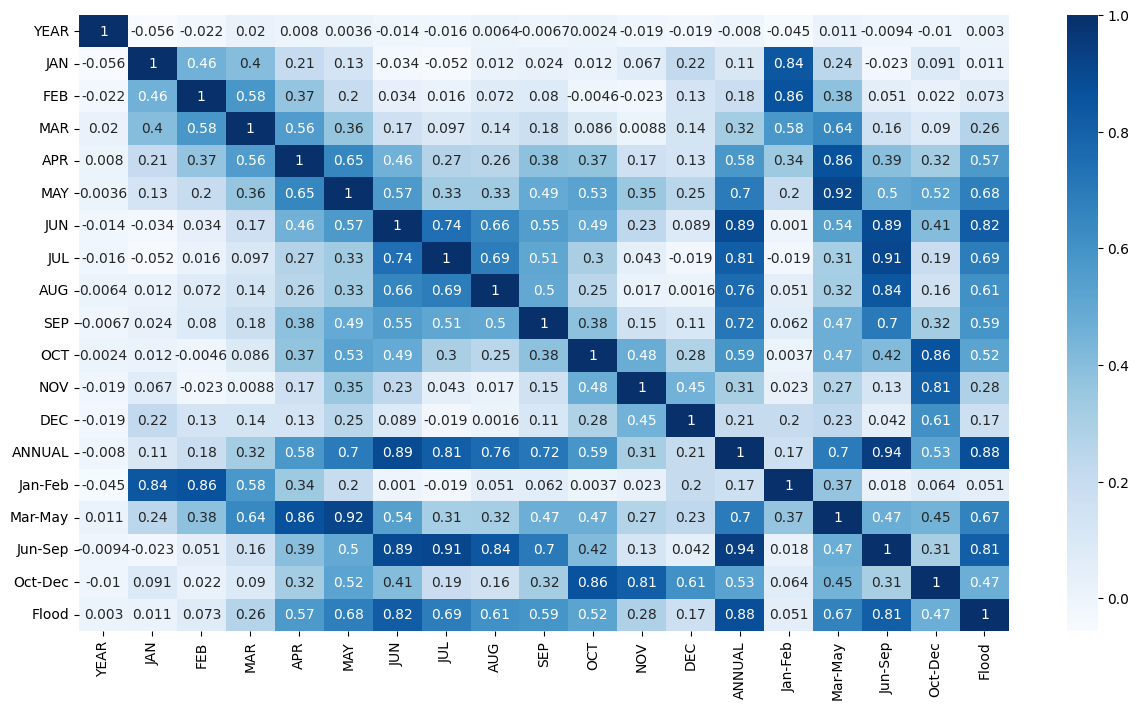

In [10]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="Blues")
plt.show()

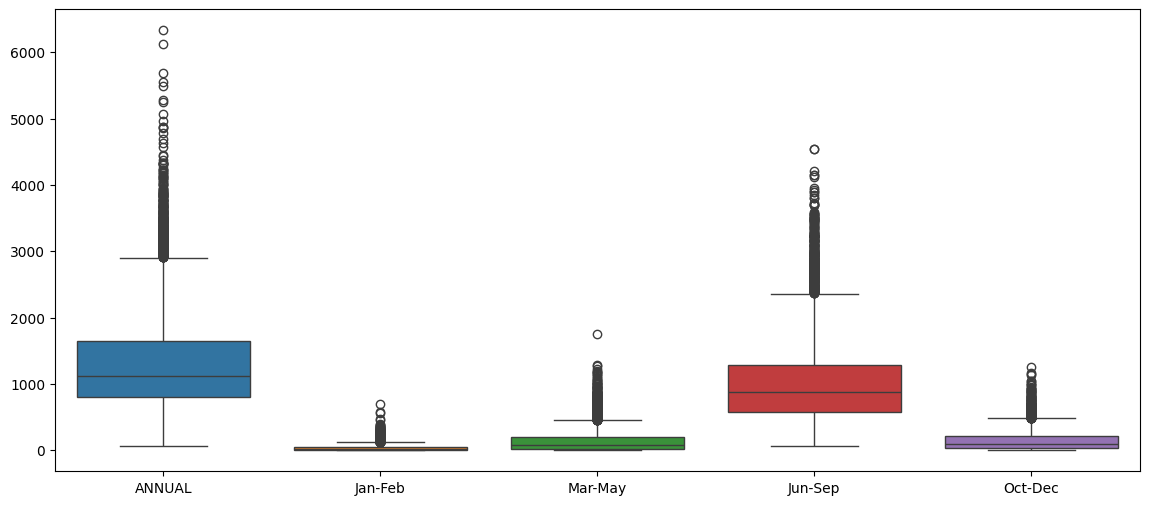

In [11]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df[["ANNUAL","Jan-Feb","Mar-May","Jun-Sep","Oct-Dec"]])
plt.show()

In [12]:
X = df[[
    "ANNUAL",
    "Jan-Feb",
    "Mar-May",
    "Jun-Sep",
    "Oct-Dec"
]]

y = df["Flood"]

In [13]:
imputer = SimpleImputer(strategy="mean")

X = imputer.fit_transform(X)

In [14]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

In [16]:
dt=DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [17]:
rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [18]:
knn=KNeighborsClassifier()

knn.fit(X_train,y_train)

KNeighborsClassifier()

In [19]:
xgb=XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [20]:
models={
    "Decision Tree":dt,
    "Random Forest":rf,
    "KNN":knn,
    "XGBoost":xgb
}

for name,model in models.items():

    pred=model.predict(X_test)

    print("="*40)
    print(name)

    print("Accuracy:",accuracy_score(y_test,pred))

    print(confusion_matrix(y_test,pred))

    print(classification_report(y_test,pred))

Decision Tree
Accuracy: 1.0
[[629   0]
 [  0 195]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       629
           1       1.00      1.00      1.00       195

    accuracy                           1.00       824
   macro avg       1.00      1.00      1.00       824
weighted avg       1.00      1.00      1.00       824

Random Forest
Accuracy: 1.0
[[629   0]
 [  0 195]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       629
           1       1.00      1.00      1.00       195

    accuracy                           1.00       824
   macro avg       1.00      1.00      1.00       824
weighted avg       1.00      1.00      1.00       824

KNN
Accuracy: 0.9963592233009708
[[628   1]
 [  2 193]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       629
           1       0.99      0.99      0.99       195

    accuracy            

In [21]:
joblib.dump(xgb,"floods.save")

joblib.dump(scaler,"scaler.save")

joblib.dump(imputer,"imputer.save")

['imputer.save']

In [22]:
files.download("floods.save")

files.download("scaler.save")

files.download("imputer.save")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
joblib.dump(imputer, "imputer.save")
from google.colab import files
files.download("imputer.save")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>